In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import ast
import emoji
from wordcloud import WordCloud
from matplotlib.colors import ListedColormap

In [42]:
df = pd.read_csv("youtubebeforecleaning.csv")
print(df.head())
print(df.tail())
print(df.info())

      video_id                                              title  \
0  INZybkX8tLI          My car charger can boil water really fast   
1  8I4Jc-WLsrs  This cassette player is built into an 8-track ...   
2  DAX2_mPr9W8  I was right about dishwasher pods, and now I c...   
3  ms8uu0zeU88      Video projectors used to be ridiculously cool   
4  Aytf6ARcs8s  Catalytic converters are simple, but getting t...   

           published_at           channel_title defaultLanguage tags  \
0  2025-11-27T18:37:52Z  Technology Connections              en   []   
1  2025-11-20T17:02:29Z  Technology Connections              en   []   
2  2025-11-04T18:07:43Z  Technology Connections              en   []   
3  2025-10-08T15:43:33Z  Technology Connections              en   []   
4  2025-10-01T15:23:12Z  Technology Connections              en   []   

   viewCount  likeCount  commentCount  
0     522237      38663          5980  
1     532178      30850          3751  
2    2445255     120581         

In [43]:
for col in df.columns:
    print(f"Column{col:}")
    print(f"Number of null values: {df[col].isnull().sum()}")
    print(f"Number of unique values: {len(df[col].value_counts())}")
    print("--------------------------------------------------------------------------------------------")

Columnvideo_id
Number of null values: 0
Number of unique values: 61786
--------------------------------------------------------------------------------------------
Columntitle
Number of null values: 0
Number of unique values: 61155
--------------------------------------------------------------------------------------------
Columnpublished_at
Number of null values: 0
Number of unique values: 61688
--------------------------------------------------------------------------------------------
Columnchannel_title
Number of null values: 0
Number of unique values: 84
--------------------------------------------------------------------------------------------
ColumndefaultLanguage
Number of null values: 2
Number of unique values: 33
--------------------------------------------------------------------------------------------
Columntags
Number of null values: 0
Number of unique values: 41431
--------------------------------------------------------------------------------------------
ColumnviewCou

In [44]:
print(f"Number of duplicates: {df.duplicated().sum()}")

Number of duplicates: 0


In [45]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numerical_features)
object_features = df.select_dtypes(include=['object']).columns.tolist() 
print(object_features)
categorical_features = ["defaultLanguage","channel_title"]

['viewCount', 'likeCount', 'commentCount']
['video_id', 'title', 'published_at', 'channel_title', 'defaultLanguage', 'tags']


C:\Users\Victus\AppData\Local\Temp\ipykernel_40184\718880229.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_features = df.select_dtypes(include=['object']).columns.tolist()


In [46]:
categorical_features = ["defaultLanguage","channel_title"]
for col in categorical_features:
    print(f"Column {col}:")
    print(df[col].value_counts())

Column defaultLanguage:
defaultLanguage
en         41989
ar          9634
en-GB       2549
vi          2000
en-US       1579
bn          1045
ta           850
ur           823
hi           514
am           447
en-IN        193
zh-Hant       40
te            27
ms            16
it            14
es            11
ml             9
fr             6
pt-PT          6
id             5
gl             5
af             4
fil            3
su             3
bn-IN          3
de             2
as             1
la             1
ja             1
nl             1
ne             1
eu             1
fi             1
Name: count, dtype: int64
Column channel_title:
channel_title
Buzz2day Tech             2000
Techno Ruhez              2000
Sufiyan Technology        2000
Velian Speaks Tech        2000
Information Technology    2000
                          ... 
Aria Technologies           34
Super Technology Man        30
Tap Tech                    20
Automation Technology       16
Rocket Tech                

In [47]:
for col in numerical_features:
    incon = df[df[col].notnull() & (df[col] < 0)]
    print(f"Coulmn: {col}")
    print(incon[col])
lang=df[df['defaultLanguage'].isna()]
print(lang)

Coulmn: viewCount
Series([], Name: viewCount, dtype: int64)
Coulmn: likeCount
Series([], Name: likeCount, dtype: int64)
Coulmn: commentCount
Series([], Name: commentCount, dtype: int64)
          video_id                                              title  \
30559  Cko8BXuWX1Q  Layers Anarc Smartwatch 5 Months Later - Impro...   
32186  a0Ok0tZZPZY  iPhone 17 Series Exclusive First Look - iPhone...   

               published_at     channel_title defaultLanguage  \
30559  2025-05-02T15:33:35Z      Venom's Tech             NaN   
32186  2025-05-02T15:41:37Z  Technical Guruji             NaN   

                                                    tags  viewCount  \
30559  ['venom', 'venom tech', "venom's tech", 'venom...     667088   
32186  ['iPhone 17 Unboxing', 'iPhone 17', 'iPhone 17...    1341640   

       likeCount  commentCount  
30559      25452          1293  
32186      19988          1225  


In [48]:
pattern = r'^[a-zA-Z0-9_-]{11}$'
df_clean = df[df['video_id'].str.match(pattern)]#منغير الايدي البايظ
rows_removed = len(df) - len(df_clean) 
print(rows_removed)
df = df_clean
df.set_index('video_id', inplace=True)
print(df.info())
print(df.loc['INZybkX8tLI'])
print(df.iloc[0])

0
<class 'pandas.DataFrame'>
Index: 61786 entries, INZybkX8tLI to A8yWoWILisY
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   title            61786 non-null  str  
 1   published_at     61786 non-null  str  
 2   channel_title    61786 non-null  str  
 3   defaultLanguage  61784 non-null  str  
 4   tags             61786 non-null  str  
 5   viewCount        61786 non-null  int64
 6   likeCount        61786 non-null  int64
 7   commentCount     61786 non-null  int64
dtypes: int64(3), str(5)
memory usage: 4.2+ MB
None
title              My car charger can boil water really fast
published_at                            2025-11-27T18:37:52Z
channel_title                         Technology Connections
defaultLanguage                                           en
tags                                                      []
viewCount                                             522237
likeCount                       

In [49]:
df['published_at'] = pd.to_datetime(df['published_at']) # datatype
df['date'] = df['published_at'].dt.date # datetime accessor
df['time'] = df['published_at'].dt.time
df['day_name'] = df['published_at'].dt.day_name()
print(df[['published_at', 'date', 'time', 'day_name']].head())
df = df.drop('published_at',axis=1)
print(df.info())

                         published_at        date      time   day_name
video_id                                                              
INZybkX8tLI 2025-11-27 18:37:52+00:00  2025-11-27  18:37:52   Thursday
8I4Jc-WLsrs 2025-11-20 17:02:29+00:00  2025-11-20  17:02:29   Thursday
DAX2_mPr9W8 2025-11-04 18:07:43+00:00  2025-11-04  18:07:43    Tuesday
ms8uu0zeU88 2025-10-08 15:43:33+00:00  2025-10-08  15:43:33  Wednesday
Aytf6ARcs8s 2025-10-01 15:23:12+00:00  2025-10-01  15:23:12  Wednesday
<class 'pandas.DataFrame'>
Index: 61786 entries, INZybkX8tLI to A8yWoWILisY
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            61786 non-null  str   
 1   channel_title    61786 non-null  str   
 2   defaultLanguage  61784 non-null  str   
 3   tags             61786 non-null  str   
 4   viewCount        61786 non-null  int64 
 5   likeCount        61786 non-null  int64 
 6   commentCount     61786 non-nu

In [50]:
lang_map = {
'en': 'English',
'en-GB': 'English',
'en-US': 'English',
'en-IN': 'English',
'ar': 'Arabic',
'vi': 'Vietnamese',    # فيتنامي
'bn': 'Bengali',       # بنغالي
'bn-IN': 'Bengali',    # بنغالي
'ta': 'Tamil',         # تاميل
'ur': 'Urdu',          # أردو
'hi': 'Hindi',         # هندي
'te': 'Telugu',        # تيلوغو
'ml': 'Malayalam',     # ماليالام
'zh-Hant': 'Chinese',  # صيني
'fil': 'Filipino',     # فلبيني
'id': 'Indonesian',    # إندونيسي
'ms': 'Malay',         # ماليزي
'ja': 'Japanese',      # ياباني
'ne': 'Nepali',        # نيبالي
'su': 'Sundanese',     # سوداني
'am': 'Amharic',       # أمهري
'es': 'Spanish',       # إسباني
'fr': 'French',        # فرنسي
'it': 'Italian',       # إيطالي
'pt-PT': 'Portuguese', # برتغالي
'de': 'German',        # ألماني
'nl': 'Dutch',         # هولندي
'gl': 'Galician',      # جاليكي
'af': 'Afrikaans',     # أفريكانز
'eu': 'Basque',        # باسك
'fi': 'Finnish',       # فنلندي
'la': 'Latin',         # لاتيني
'as': 'Assamese'     # آسامي
}
df['defaultLanguage'] = df['defaultLanguage'].map(lang_map)
df['defaultLanguage'] = df['defaultLanguage'].fillna('English')
print(df['defaultLanguage'].value_counts())
for col in categorical_features:
    df[col] = df[col].astype('category')

defaultLanguage
English       46312
Arabic         9634
Vietnamese     2000
Bengali        1048
Tamil           850
Urdu            823
Hindi           514
Amharic         447
Chinese          40
Telugu           27
Malay            16
Italian          14
Spanish          11
Malayalam         9
French            6
Portuguese        6
Indonesian        5
Galician          5
Afrikaans         4
Filipino          3
Sundanese         3
German            2
Assamese          1
Latin             1
Japanese          1
Dutch             1
Nepali            1
Basque            1
Finnish           1
Name: count, dtype: int64


In [51]:
df['tags'] = df['tags'].apply(ast.literal_eval)
def clean_list(lst):
    cleaned = []
    for x in lst:
        x = x.lower().strip()                 
        x = re.sub(r'[^A-Za-z0-9\s]+', '', x)   
        x = x.strip()
        if x not in cleaned and x != "":              
            cleaned.append(x)
    return cleaned
df['tags'] = df['tags'].apply(clean_list)
print(df['tags'])
df['num_of_tags'] = df['tags'].apply(len)
print(df.info())

video_id
INZybkX8tLI                                                   []
8I4Jc-WLsrs                                                   []
DAX2_mPr9W8                                                   []
ms8uu0zeU88                                                   []
Aytf6ARcs8s                                                   []
                                     ...                        
5p-B51FKEps    [brick technology, lego technic, technic, tech...
eZlqNb-eqe8    [brick technology, lego technic, technic, tech...
V40zQIfnS4M    [brick technology, lego technic, technic, tech...
Nqh-1P615CE    [brick technology, lego technic, technic, tech...
A8yWoWILisY    [brick technology, lego technic, technic, tech...
Name: tags, Length: 61786, dtype: object
<class 'pandas.DataFrame'>
Index: 61786 entries, INZybkX8tLI to A8yWoWILisY
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   title            61786 non-

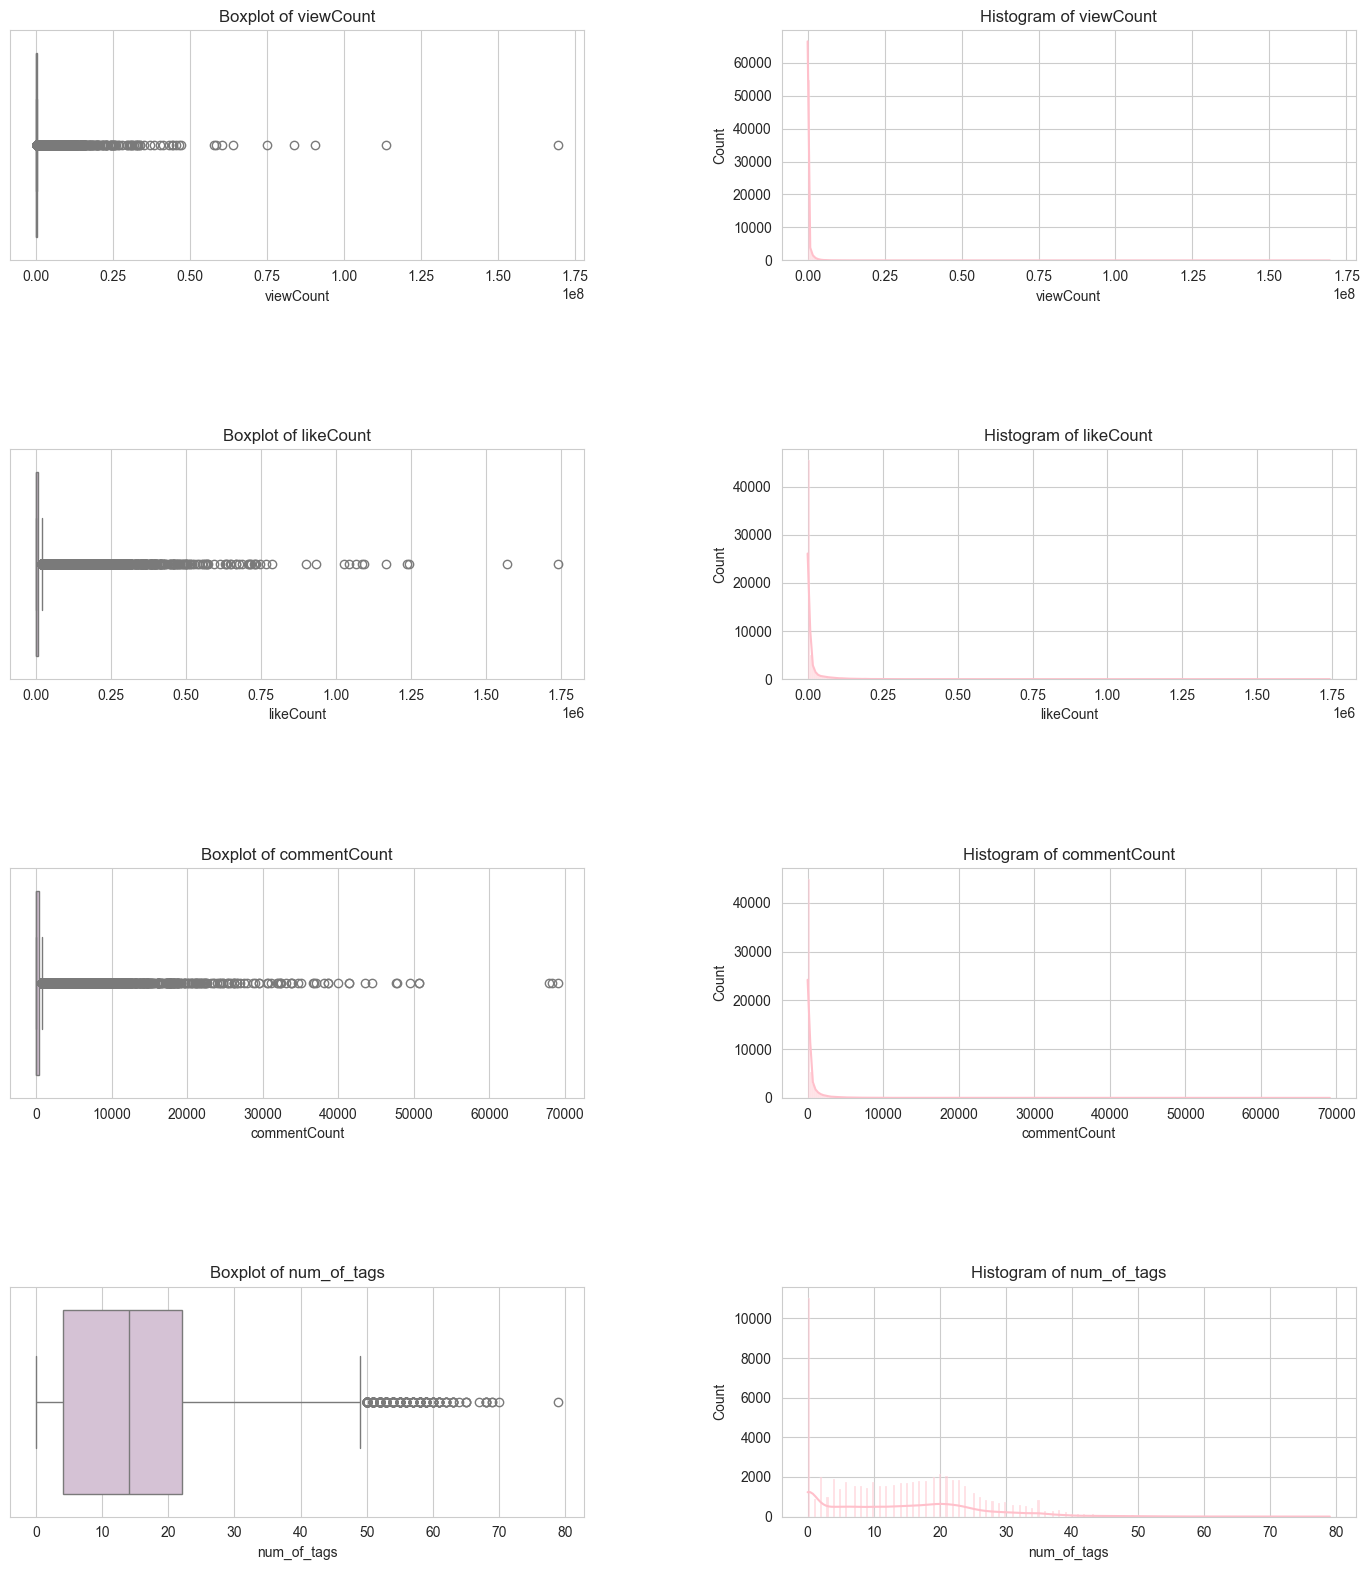

In [52]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
df[numerical_features].describe()
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(16, 4.5 * len(numerical_features)))

for i, col in enumerate(numerical_features):
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 0], color='thistle')
    axes[i, 0].set_title(f'Boxplot of {col}')

    # Histogram
    sns.histplot(df[col], bins=250, ax=axes[i, 1], kde=True, color='pink')
    axes[i, 1].set_title(f'Histogram of {col}')
plt.tight_layout(pad = 9)
plt.show()


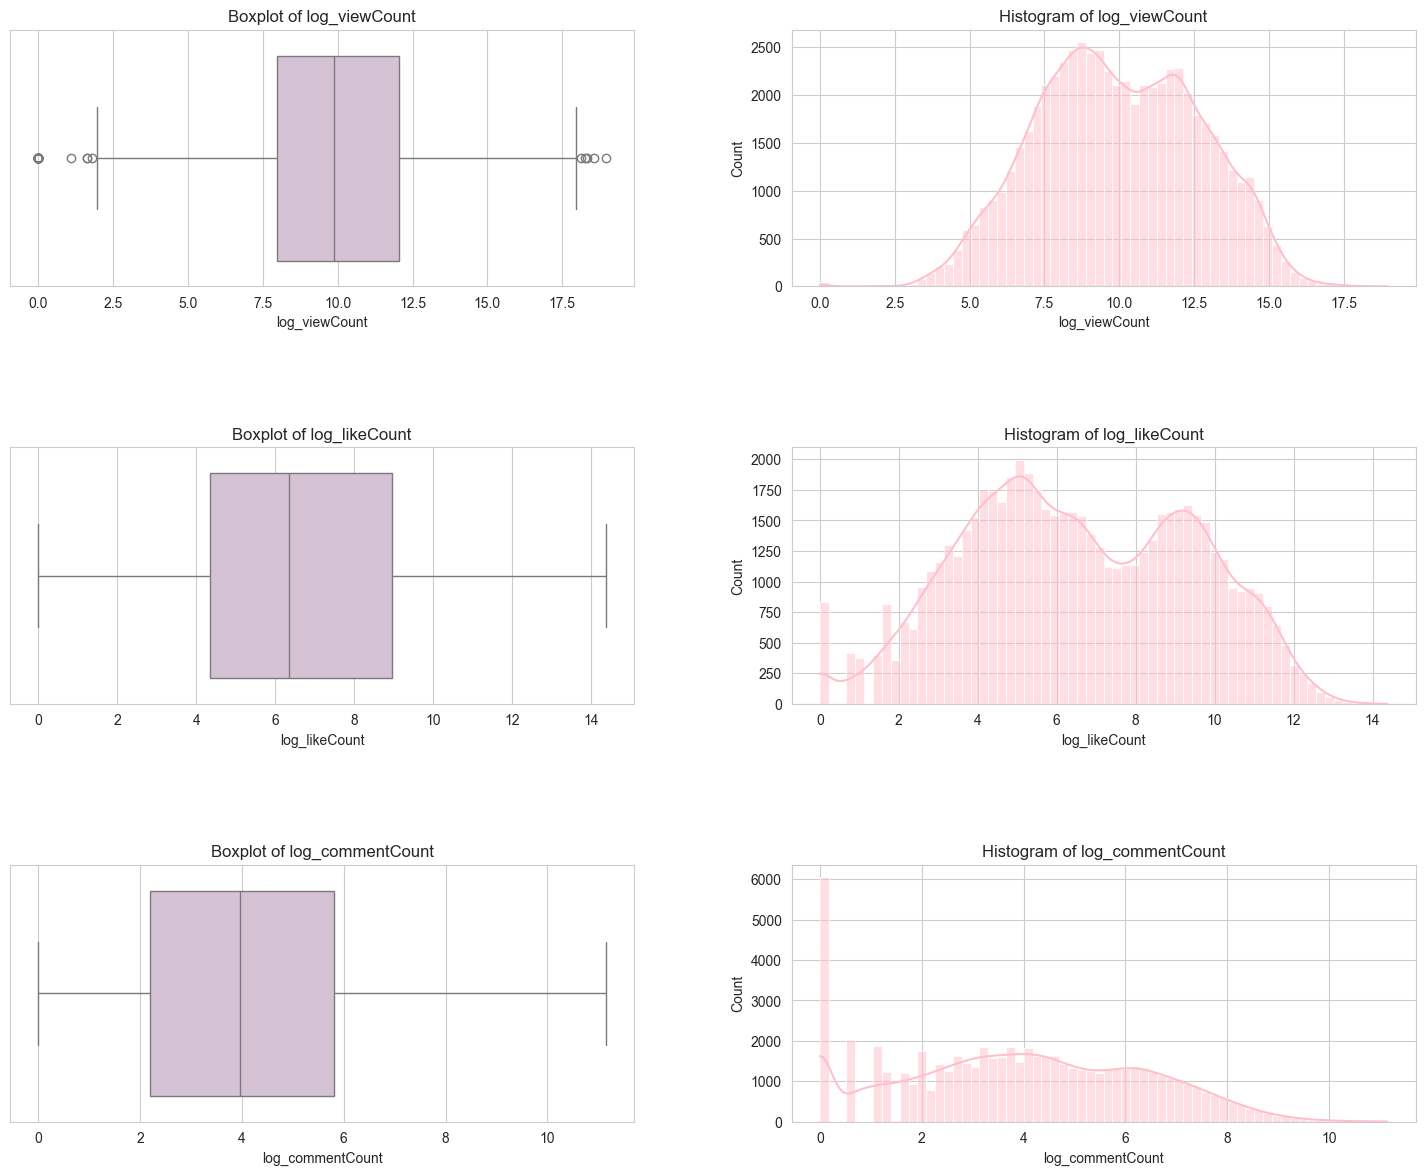

In [53]:
log_cols = ["viewCount","likeCount","commentCount"]
for col in log_cols:
    df[f"log_{col}"] = np.log1p(df[col])
log_cols = [f"log_{c}" for c in log_cols]

fig, axes = plt.subplots(len(log_cols), 2, figsize=(16, 4.5 * len(log_cols)))

for i, col in enumerate(log_cols):
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 0], color='thistle')
    axes[i, 0].set_title(f'Boxplot of {col}')

    # Histogram
    sns.histplot(df[col], bins=64, ax=axes[i, 1], kde=True, color='pink')
    axes[i, 1].set_title(f'Histogram of {col}')

plt.tight_layout(pad = 7)
plt.show()

In [54]:
df[numerical_features].describe()

,viewCount,likeCount,commentCount,num_of_tags
count,6.178600e+04,6.178600e+04,61786.000000,61786.000000
mean,3.629179e+05,1.326421e+04,516.313437,14.142314
std,1.759378e+06,4.203093e+04,1764.048158,11.506892
min,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,2.907250e+03,7.600000e+01,8.000000,4.000000
50%,1.940750e+04,5.660000e+02,51.000000,14.000000
75%,1.680982e+05,7.792000e+03,334.000000,22.000000
max,1.696354e+08,1.741715e+06,69123.000000,79.000000


In [55]:
def remove_emoji(text):
    return emoji.replace_emoji(text, replace="")
df["title"] = df["title"].apply(remove_emoji)

In [56]:
print(df.info())
df.to_csv("youtubeaftercleaning.csv", index=False, encoding="utf-8-sig")

<class 'pandas.DataFrame'>
Index: 61786 entries, INZybkX8tLI to A8yWoWILisY
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   title             61786 non-null  str     
 1   channel_title     61786 non-null  category
 2   defaultLanguage   61786 non-null  category
 3   tags              61786 non-null  object  
 4   viewCount         61786 non-null  int64   
 5   likeCount         61786 non-null  int64   
 6   commentCount      61786 non-null  int64   
 7   date              61786 non-null  object  
 8   time              61786 non-null  object  
 9   day_name          61786 non-null  str     
 10  num_of_tags       61786 non-null  int64   
 11  log_viewCount     61786 non-null  float64 
 12  log_likeCount     61786 non-null  float64 
 13  log_commentCount  61786 non-null  float64 
dtypes: category(2), float64(3), int64(4), object(3), str(2)
memory usage: 8.3+ MB
None


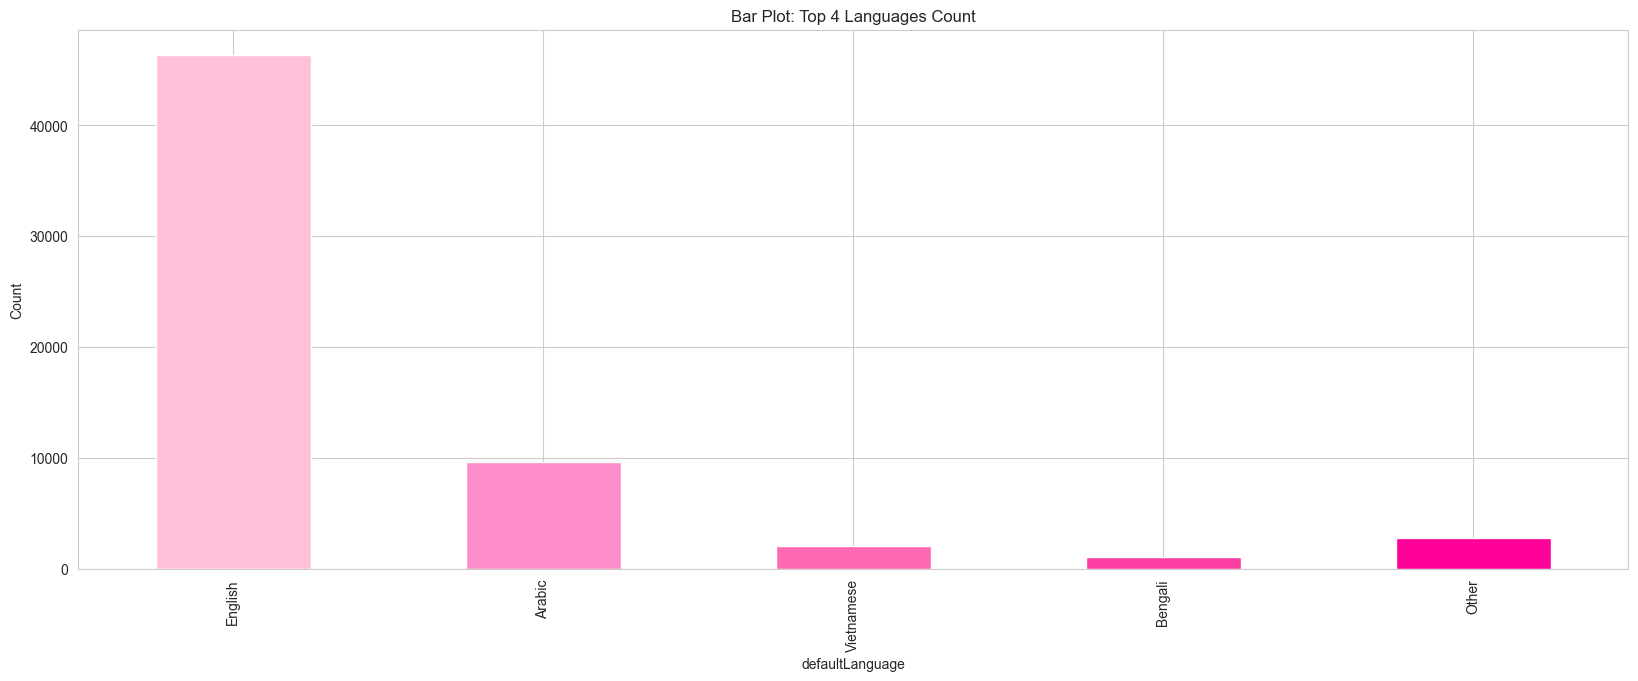

In [57]:
plt.figure(figsize=(20, 7))
top4_languages = df['defaultLanguage'].value_counts().head(4).index.tolist()
df['language_grouped'] = df['defaultLanguage'].apply(lambda x: x if x in top4_languages else 'Other')
language_counts = df['language_grouped'].value_counts()
language_counts = language_counts.reindex(top4_languages + ['Other'])
colors = ["#FFC0DA", "#FC8DC8", "#FF69B4", "#FF3EA5", "#FF0099"]  
language_counts.plot(kind='bar', color=colors)
plt.xlabel("defaultLanguage")
plt.ylabel("Count")
plt.title('Bar Plot: Top 4 Languages Count')
plt.show()

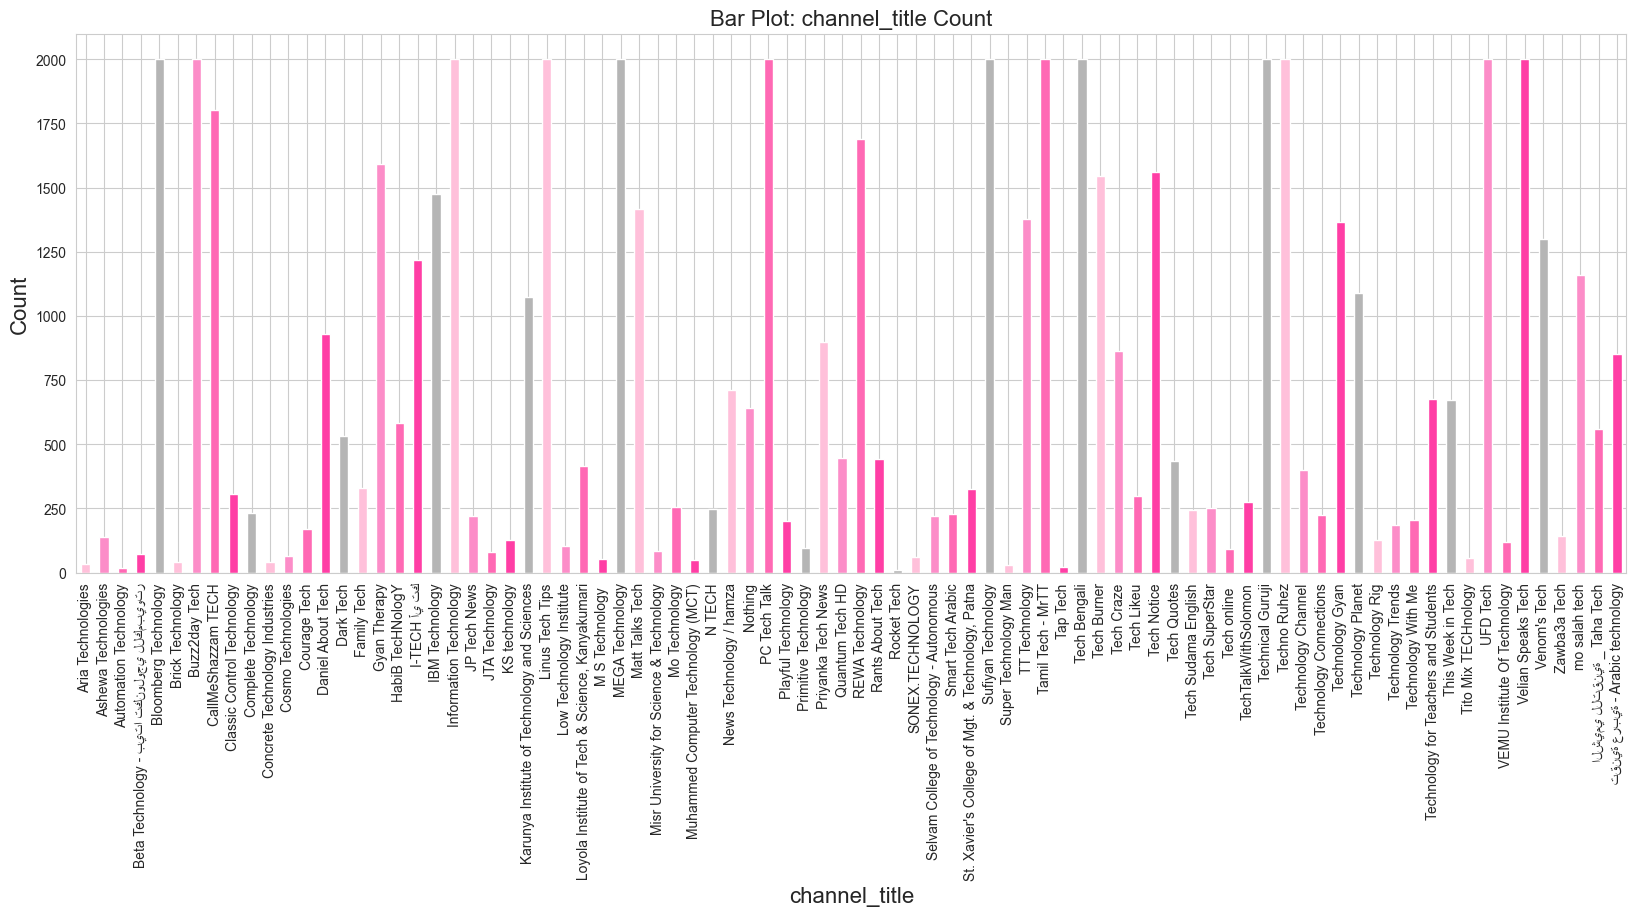

In [58]:
plt.figure(figsize=(20,7))
colors = ["#FFC0DA", "#FC8DC8", "#FF69B4", "#FF3EA5", "#B5B5B5"] 

df['channel_title'].value_counts().sort_index().plot(kind="bar",color=colors)
plt.xlabel("channel_title",fontsize = 16)
plt.ylabel("Count",fontsize = 16)
plt.title('Bar Plot: channel_title Count', fontsize = 16)
plt.show()

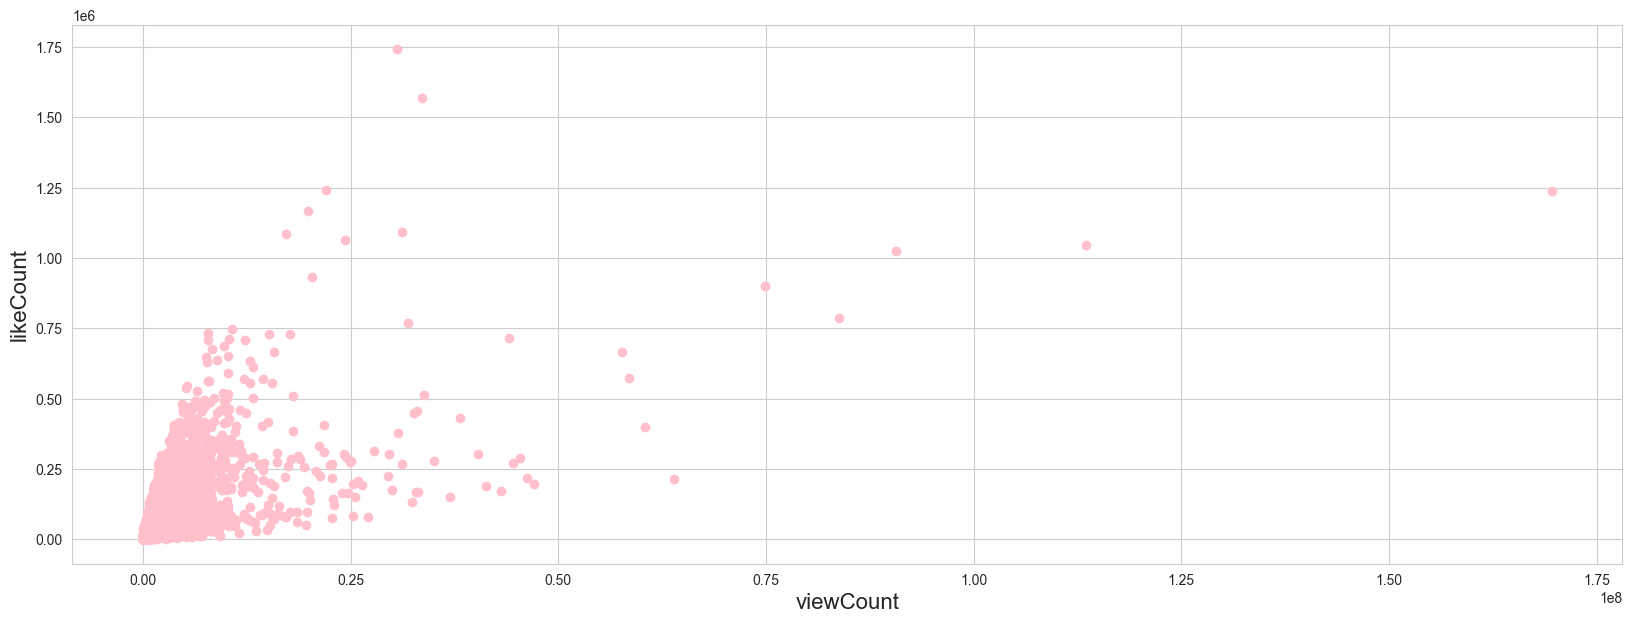

In [59]:
plt.figure(figsize=(20,7))
plt.scatter(df["viewCount"],df["likeCount"],color="pink")
plt.xlabel("viewCount",fontsize = 16)
plt.ylabel("likeCount",fontsize = 16)
plt.show()

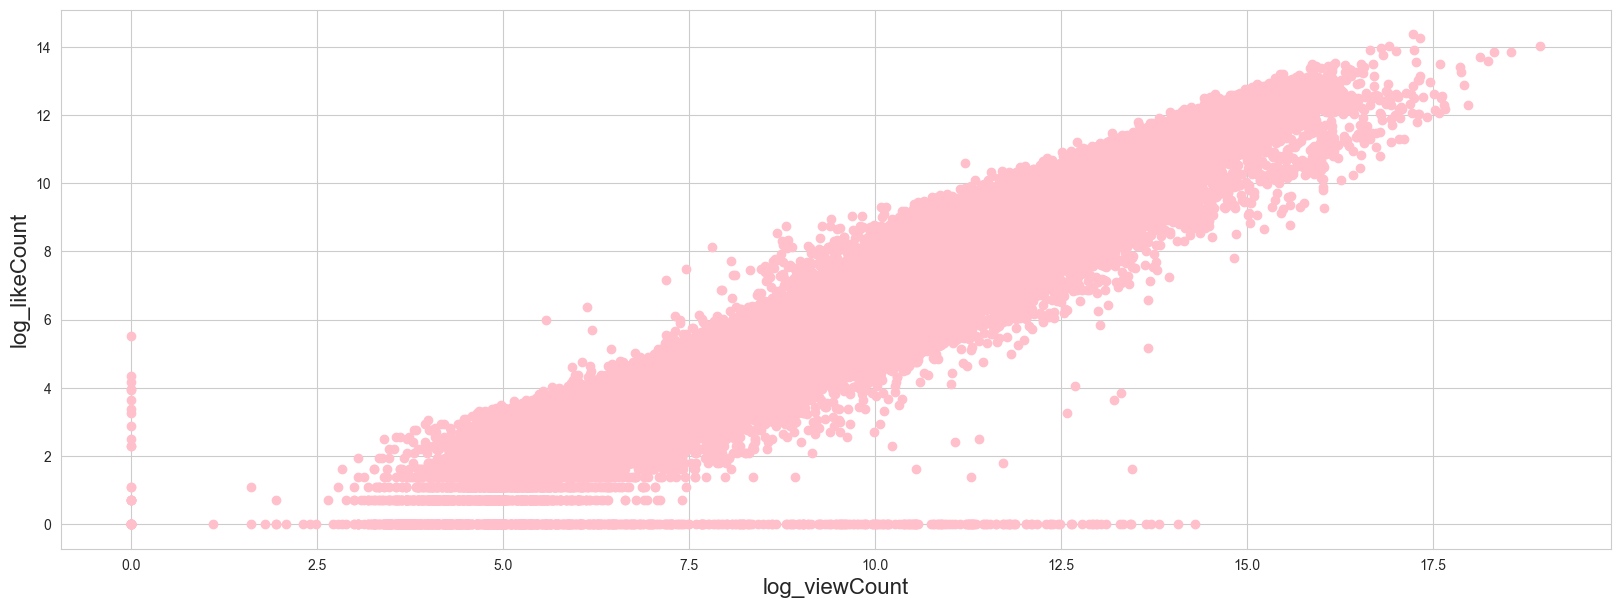

In [60]:
plt.figure(figsize=(20,7))
plt.scatter(df["log_viewCount"],df["log_likeCount"],color="pink")
plt.xlabel("log_viewCount",fontsize = 16)
plt.ylabel("log_likeCount",fontsize = 16)
plt.show()

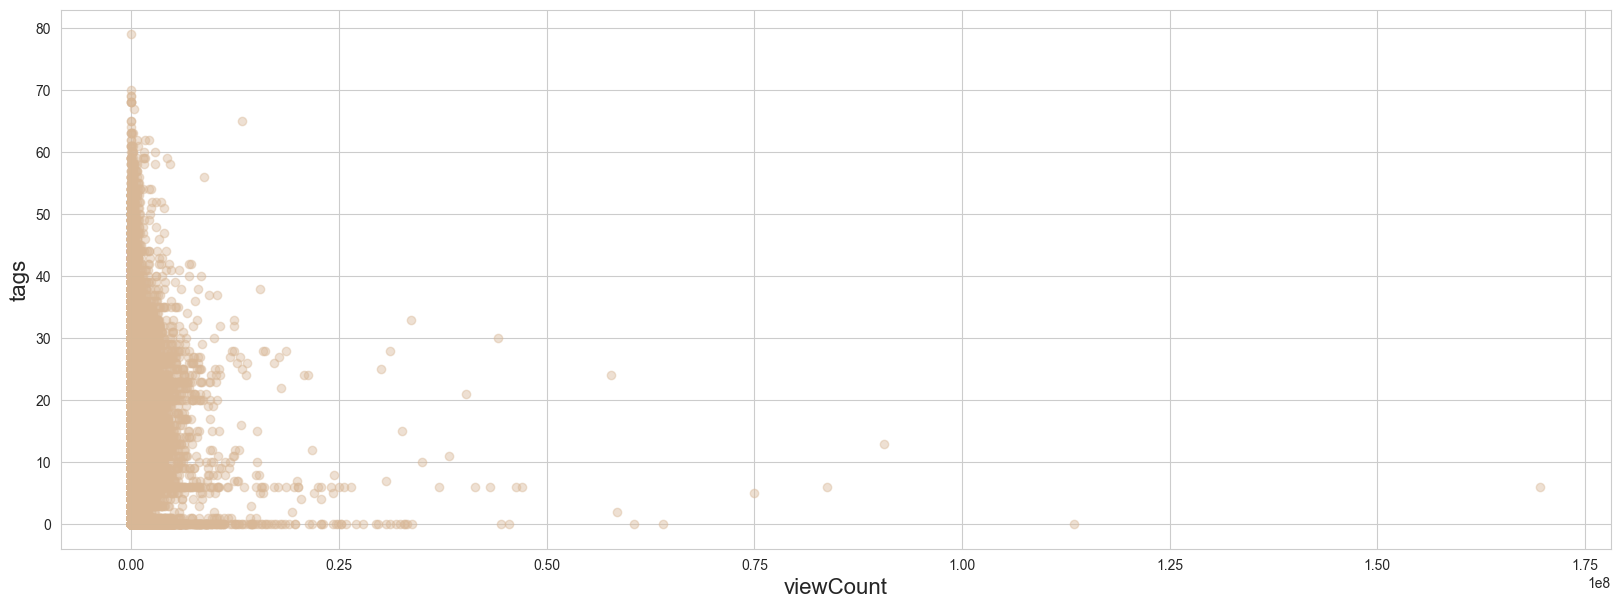

In [61]:
plt.figure(figsize=(20,7))
plt.scatter(df["viewCount"],df["num_of_tags"],color="#D8B7966B")
plt.xlabel("viewCount",fontsize = 16)
plt.ylabel("tags",fontsize = 16)
plt.show()

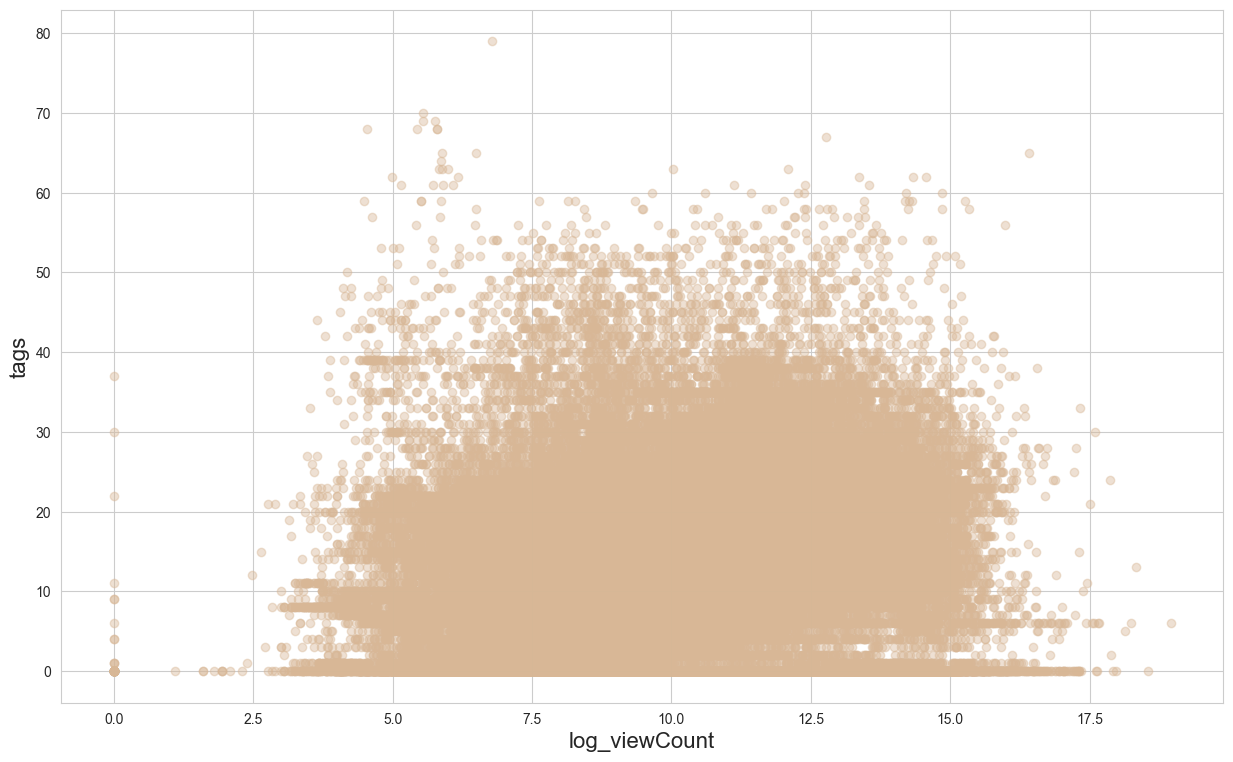

In [62]:
plt.figure(figsize=(15,9))
plt.scatter(df["log_viewCount"],df["num_of_tags"],color="#D8B7966B")
plt.xlabel("log_viewCount",fontsize = 16)
plt.ylabel("tags",fontsize = 16)
plt.show()

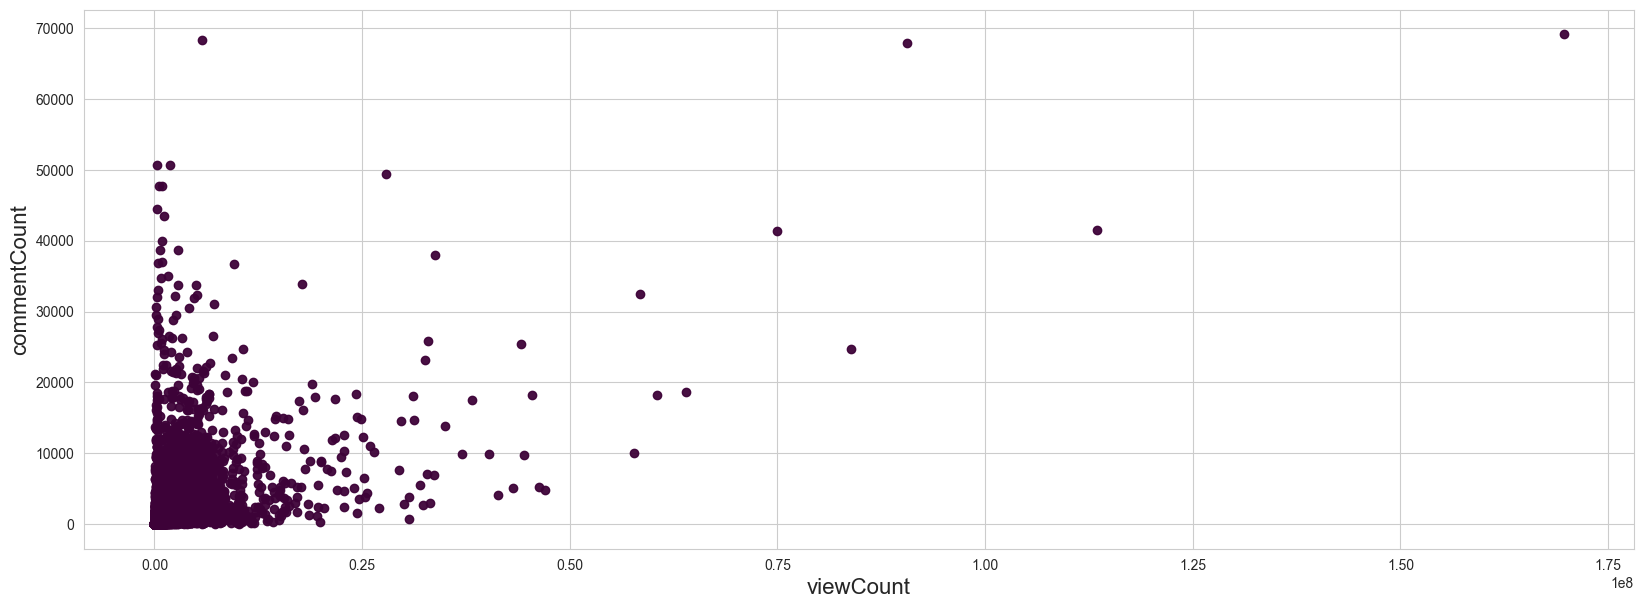

In [63]:
plt.figure(figsize=(20,7))
plt.scatter(df["viewCount"],df["commentCount"],color="#3D0238F1")
plt.xlabel("viewCount",fontsize = 16)
plt.ylabel("commentCount",fontsize = 16)
plt.show()

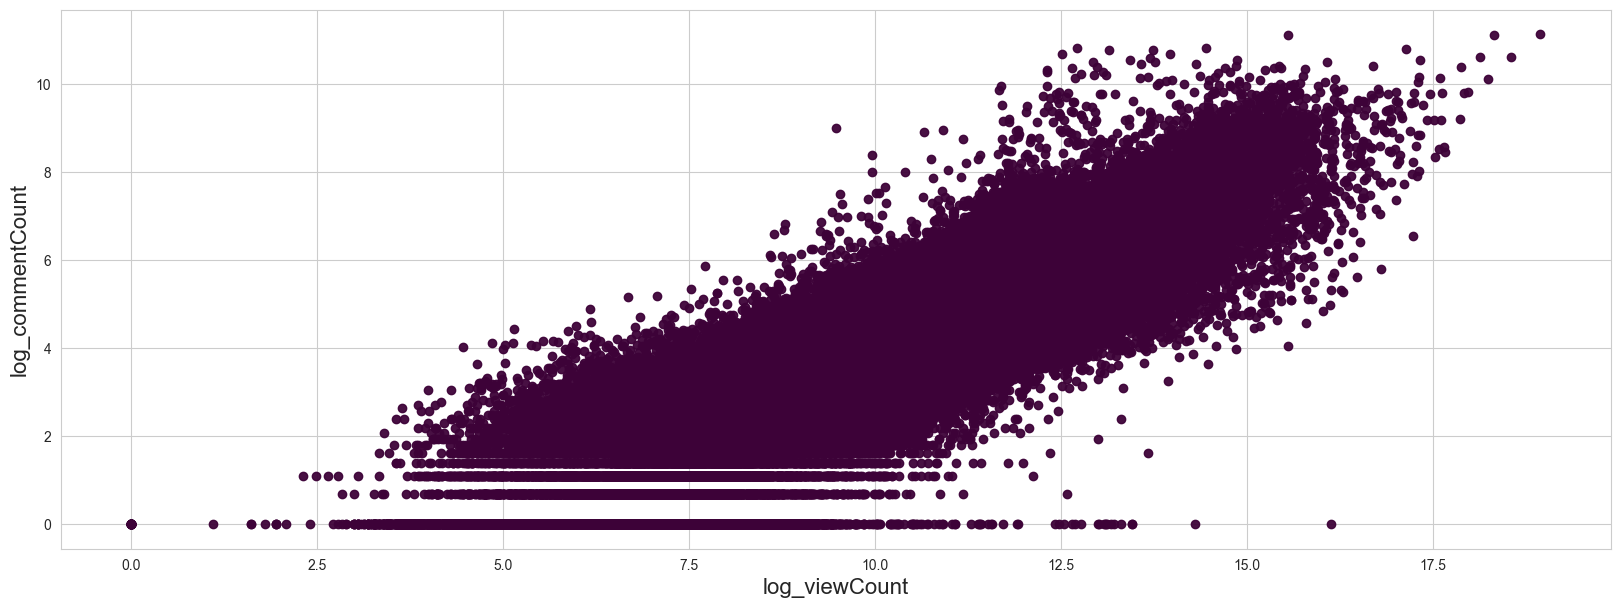

In [64]:
plt.figure(figsize=(20,7))
plt.scatter(df["log_viewCount"],df["log_commentCount"],color="#3D0238F1")
plt.xlabel("log_viewCount",fontsize = 16)
plt.ylabel("log_commentCount",fontsize = 16)
plt.show()

C:\Users\Victus\AppData\Local\Temp\ipykernel_40184\353959954.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tags.values, y=top_tags.index, palette="Purples")


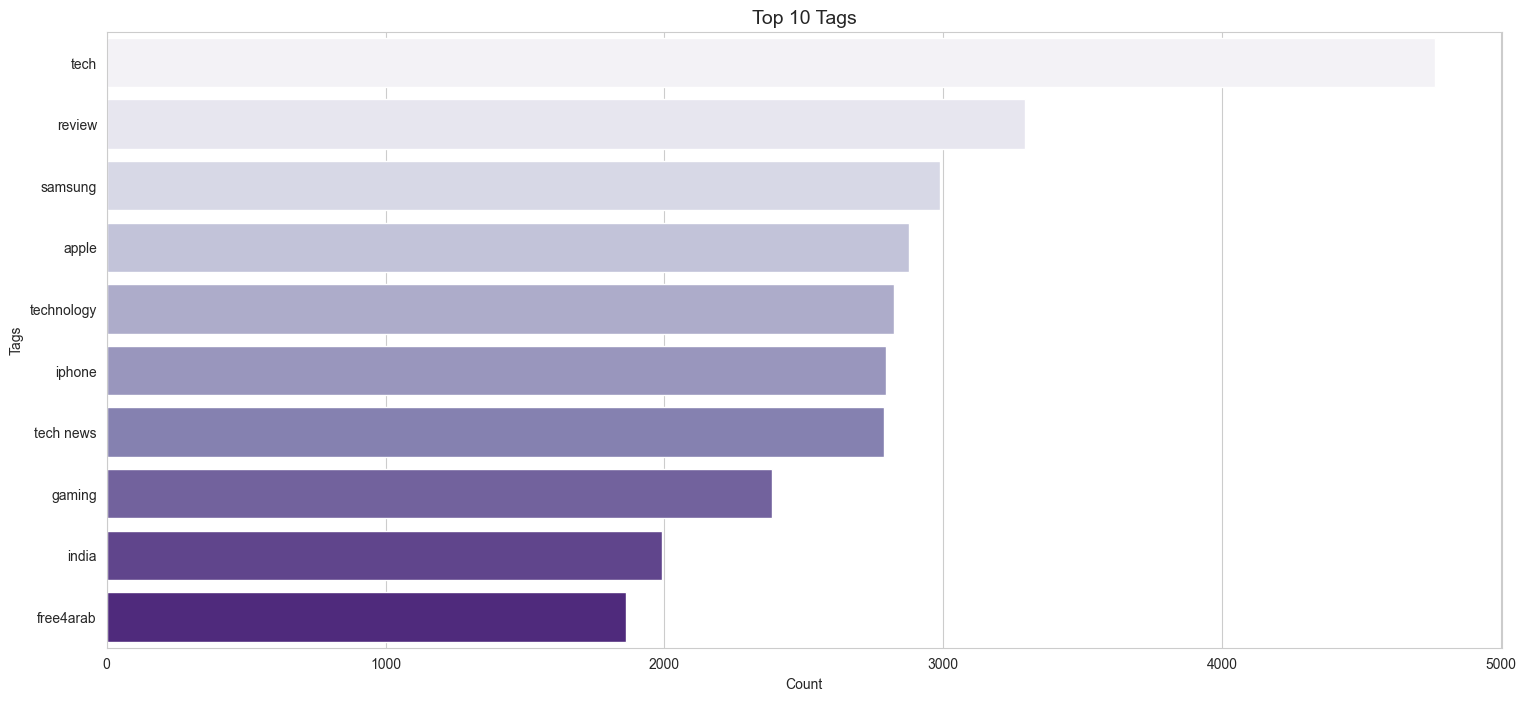

In [65]:
all_tags = [tag for tags in df['tags'] for tag in tags]
tag_counts = pd.Series(all_tags).value_counts()
top_tags = tag_counts.head(10)
plt.figure(figsize=(18, 8))
c=["#820404DE","#820404DF","#820404BA","#8204049A","#82040482","#8204046F","#82040461","#8204045E","#82040445","#82040439"]
sns.barplot(x=top_tags.values, y=top_tags.index, palette="Purples")
plt.title('Top 10 Tags', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Tags')
plt.show()


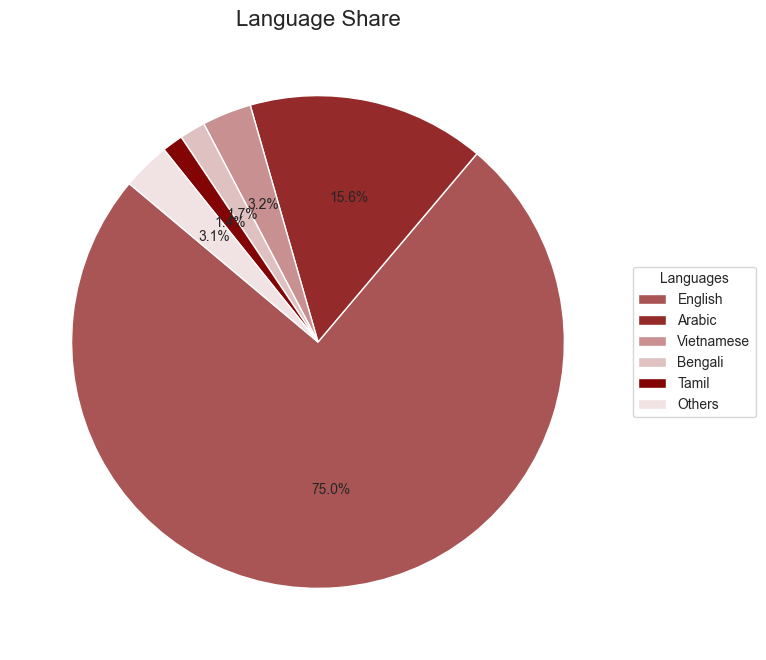

In [66]:


plt.figure(figsize=(18,8))
lang_counts = df['defaultLanguage'].value_counts()
if len(lang_counts) > 5:
    top_5 = lang_counts[:5]
    others = pd.Series([lang_counts[5:].sum()], index=['Others'])
    lang_counts = pd.concat([top_5, others])
c=["#820404AD","#820404D9","#82040470","#8204043F","#820404FF","#8204041C"]
patches, texts, autotexts = plt.pie(lang_counts, labels=None, autopct='%1.1f%%', colors=c, startangle=140)
plt.title('Language Share', fontsize=16)
plt.legend(patches, lang_counts.index, title="Languages", loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()


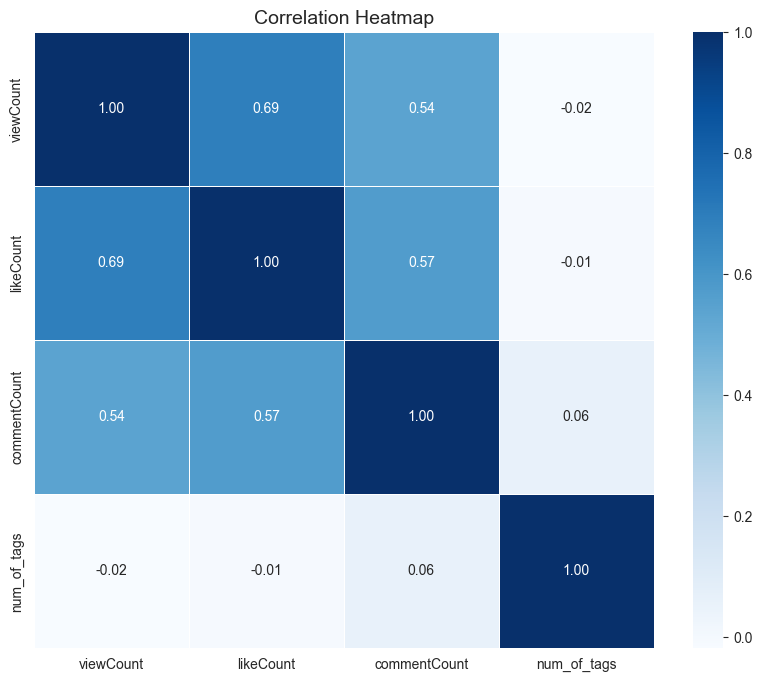

In [67]:
plt.figure(figsize=(10, 8))
cols = ['viewCount', 'likeCount', 'commentCount', 'num_of_tags']
corr = df[cols].corr()

sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap', fontsize=14)
plt.show()

C:\Users\Victus\AppData\Local\Temp\ipykernel_40184\1317859924.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daily_views.index, y=daily_views.values, palette=colors)


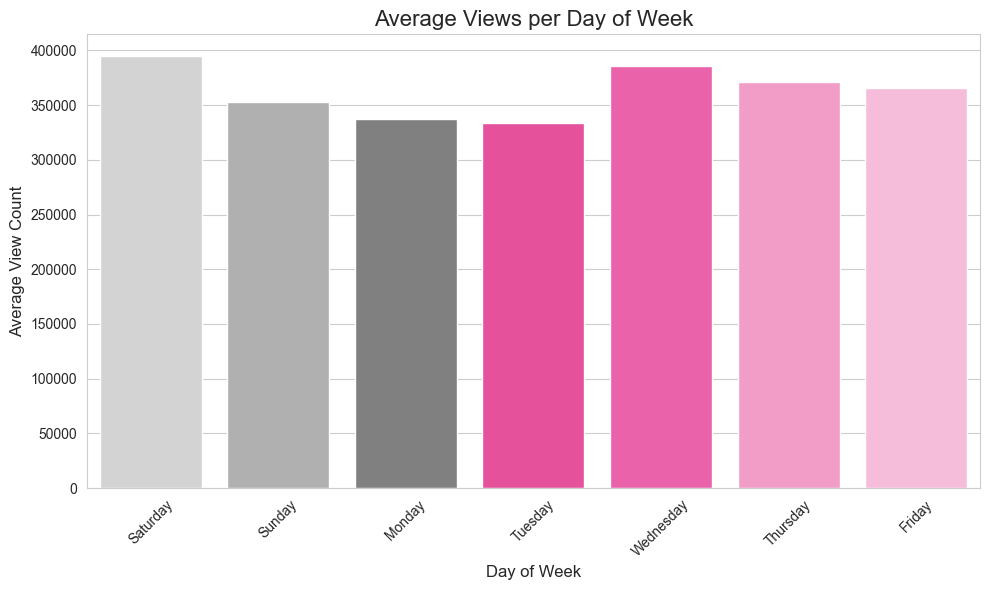

In [68]:
days_order = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
daily_views = df.groupby('day_name')['viewCount'].mean().reindex(days_order)
colors = [ "#D3D3D3", "#B0B0B0", "#808080", "#FF389C", "#FF4CABDC", "#FF8FC7", "#FFB4DC"]  
plt.figure(figsize=(10, 6))
sns.barplot(x=daily_views.index, y=daily_views.values, palette=colors)
plt.title('Average Views per Day of Week', fontsize=16)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Average View Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend([], [], frameon=False)
plt.tight_layout()
plt.show()

<Figure size 2000x800 with 0 Axes>

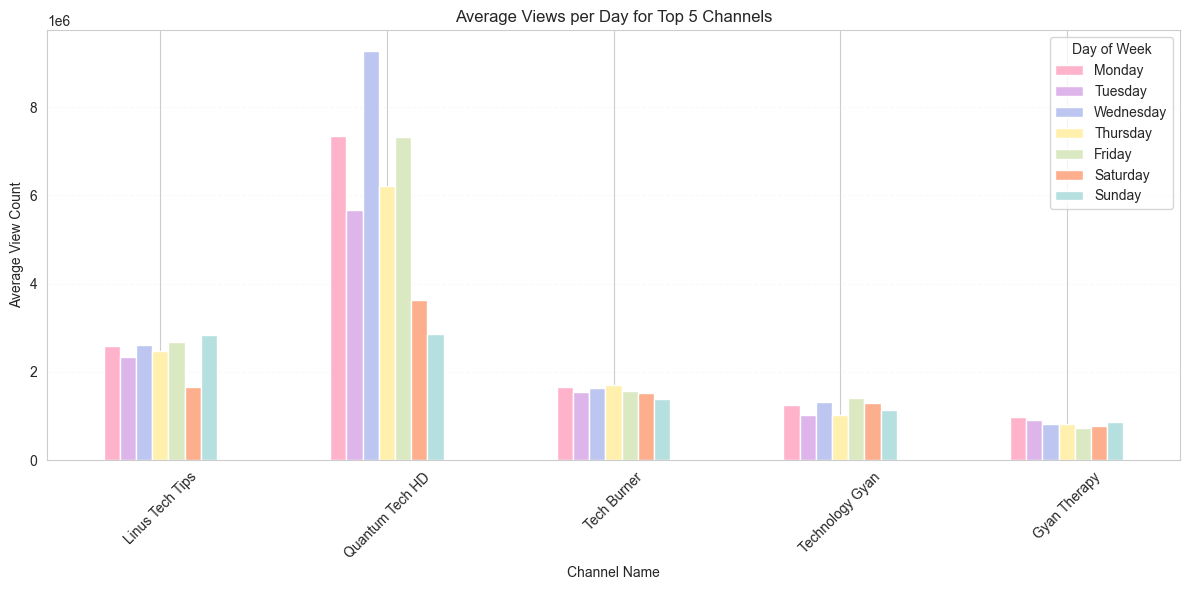

In [69]:
top_channels = (df.groupby('channel_title')['viewCount'].sum().sort_values(ascending=False).head(5).index.tolist())
df_top = df[df['channel_title'].isin(top_channels)]
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
grouped_data = (df_top.groupby(['channel_title', 'day_name'])['viewCount'].mean().unstack().reindex(columns=days_order))
grouped_data = grouped_data.loc[top_channels]
plt.figure(figsize=(20, 8))
colors = {
    'Monday':     "#FFB3CB",
    'Tuesday':    "#DEB5EA",
    'Wednesday':  "#BCC6F0",
    'Thursday':   "#FFF0AD",
    'Friday':     "#DAE9C2",
    'Saturday':   "#FCAE8D",
    'Sunday':     "#B6DFDF"
}
grouped_data.plot(kind='bar',figsize=(12, 6),color=[colors[col] for col in grouped_data.columns])
plt.title('Average Views per Day for Top 5 Channels')
plt.ylabel('Average View Count')
plt.xlabel('Channel Name')
plt.xticks(rotation=45)
plt.legend(title='Day of Week')
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

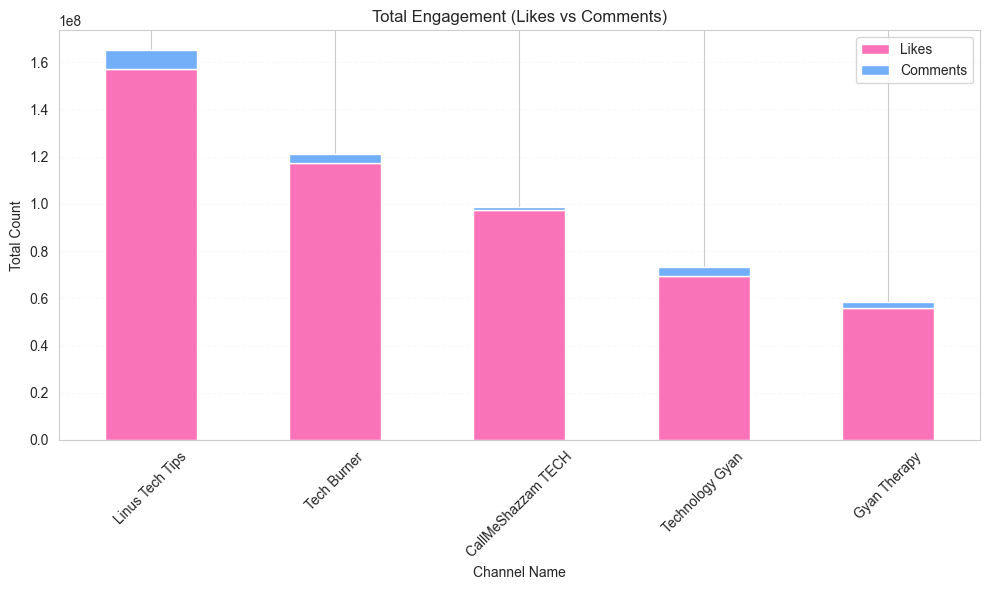

In [70]:
stacked_data = df.groupby('channel_title')[['likeCount', 'commentCount']].sum()
top_channels = stacked_data.sum(axis=1).sort_values(ascending=False).head(5).index.tolist()
stacked_data = stacked_data.loc[top_channels]
plt.figure(figsize=(10, 6))
stacked_data.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#F873B8", "#73AFF8"])
plt.title('Total Engagement (Likes vs Comments)')
plt.ylabel('Total Count')
plt.xlabel('Channel Name')
plt.xticks(rotation=45)
plt.legend(['Likes', 'Comments'])
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.tight_layout()
plt.show()

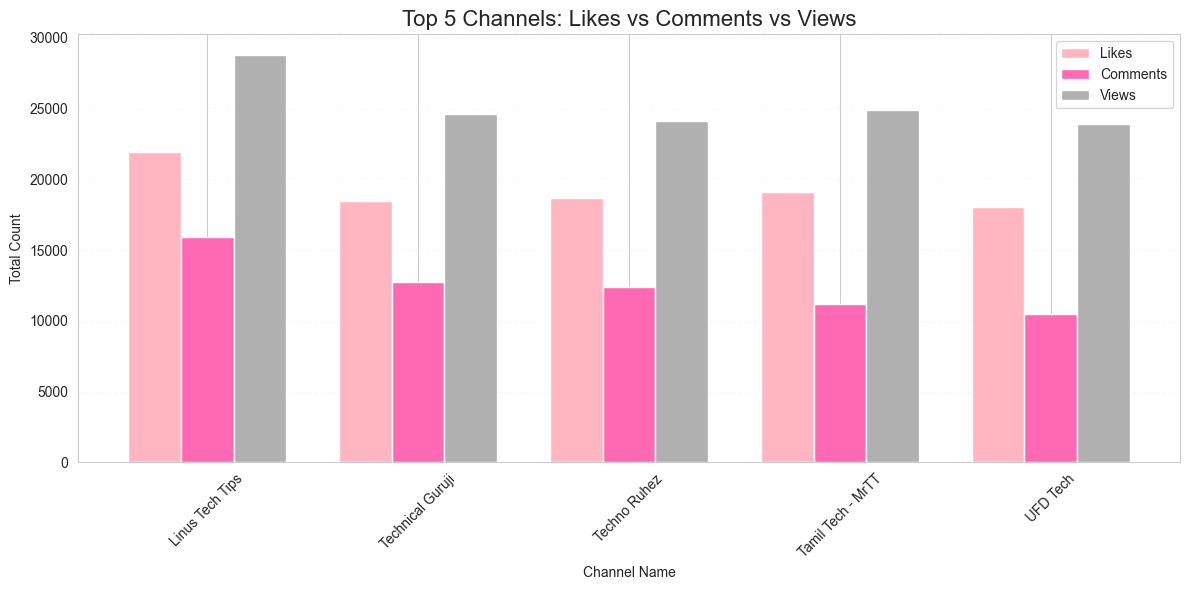

In [71]:
engagement_cols = ['log_likeCount', 'log_commentCount', 'log_viewCount']  
top_channels = (df.groupby('channel_title')[engagement_cols].sum().sum(axis=1).sort_values(ascending=False).head(5).index.tolist())
grouped_data = df.groupby('channel_title')[engagement_cols].sum()
grouped_data = grouped_data.loc[top_channels]
plt.figure(figsize=(12, 6))
bar_width = 0.25
x = np.arange(len(top_channels))  
plt.bar(x - bar_width, grouped_data['log_likeCount'], width=bar_width, color='#FFB6C1', label='Likes')
plt.bar(x, grouped_data['log_commentCount'], width=bar_width, color='#FF69B4', label='Comments')
plt.bar(x + bar_width, grouped_data['log_viewCount'], width=bar_width, color='#B0B0B0', label='Views')  
plt.title('Top 5 Channels: Likes vs Comments vs Views', fontsize=16)
plt.ylabel('Total Count')
plt.xlabel('Channel Name')
plt.xticks(x, top_channels, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.tight_layout()
plt.show()

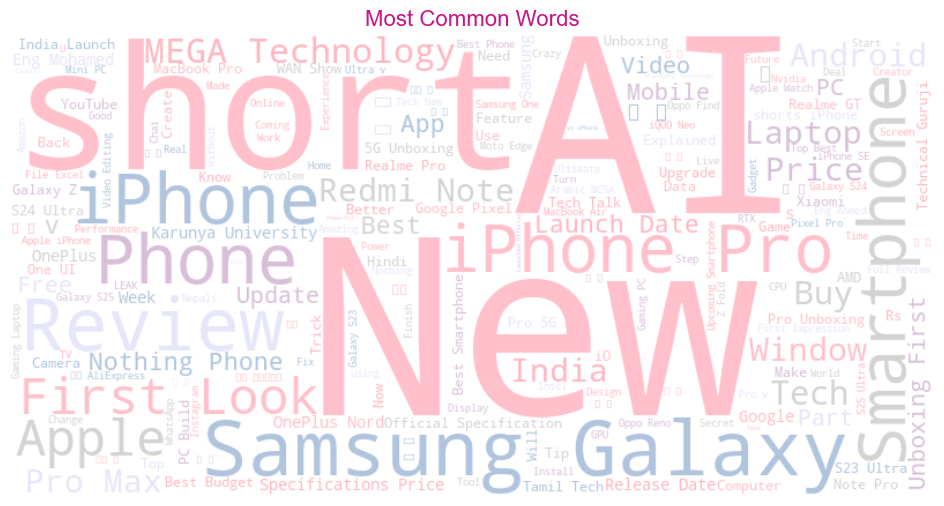

In [72]:
plt.figure(figsize=(12, 6))
text = " ".join(title for title in df['title'].astype(str))
colors = ["#FFC0CB", "#FFB6C1", "#D8BFD8", "#E6E6FA", "#B0C4DE", "#D3D3D3"]
cmap = ListedColormap(colors)
wordcloud = WordCloud(width=800,height=400,background_color='white',colormap=cmap,contour_color='#C71585',contour_width=1,max_words=200,random_state=42).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words', color='#C71585', fontsize=16)
plt.show()

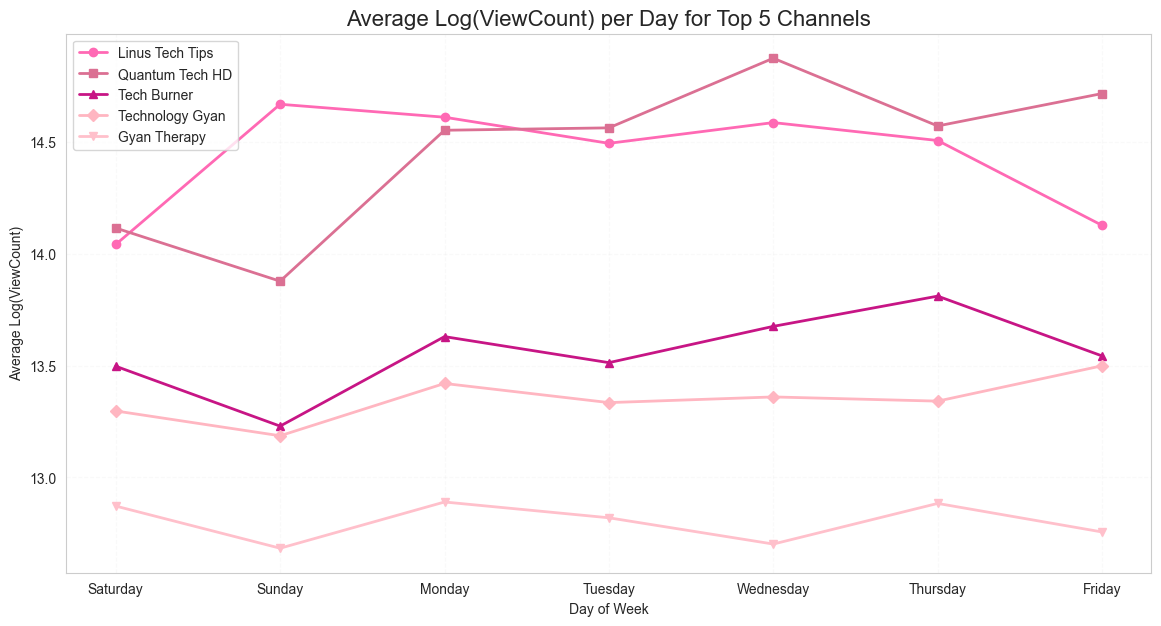

In [73]:
days_order = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
top_channels = df.groupby('channel_title')['viewCount'].sum().sort_values(ascending=False).head(5).index.tolist()
df_top = df[df['channel_title'].isin(top_channels)]
colors = ['#FF69B4', '#DB7093', '#C71585', '#FFB6C1', '#FFC0CB']
markers = ['o', 's', '^', 'D', 'v']
plt.figure(figsize=(14,7))
for i, channel in enumerate(top_channels):
    channel_data = df_top[df_top['channel_title'] == channel] \
    .groupby('day_name')['log_viewCount'].mean() \
    .reindex(days_order)
    plt.plot(channel_data.index, channel_data.values, marker=markers[i], linewidth=2, color=colors[i], label=channel)
plt.title('Average Log(ViewCount) per Day for Top 5 Channels', fontsize=16)
plt.xlabel('Day of Week')
plt.ylabel('Average Log(ViewCount)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.1)
plt.show()

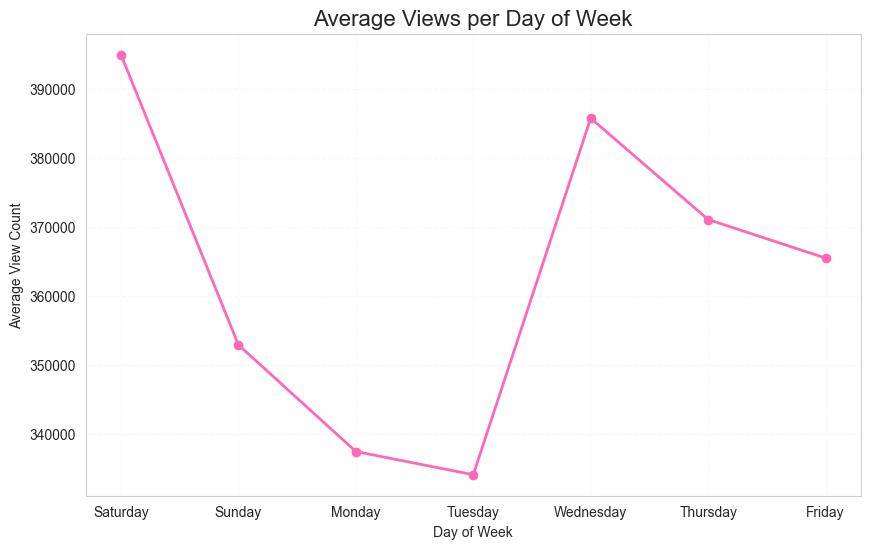

In [74]:
days_order = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
daily_views = df.groupby('day_name')['viewCount'].mean().reindex(days_order)
plt.figure(figsize=(10,6))
plt.plot(daily_views.index, daily_views.values, marker='o', color='#FF69B4', linewidth=2)
plt.title('Average Views per Day of Week', fontsize=16)
plt.xlabel('Day of Week')
plt.ylabel('Average View Count')
plt.grid(True, linestyle='--', alpha=0.1)
plt.show()

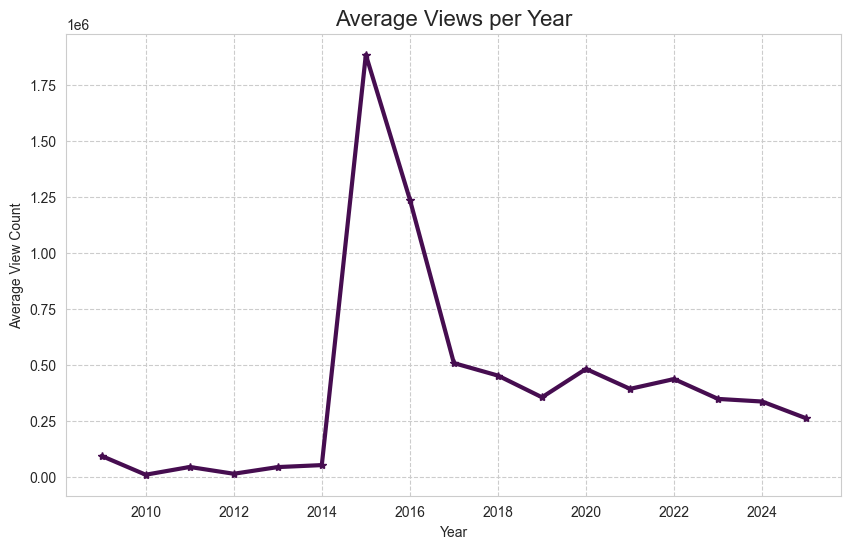

In [75]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
yearly_views = df.groupby('year')['viewCount'].mean()
plt.figure(figsize=(10,6))
plt.plot(yearly_views.index, yearly_views.values, marker='*', color="#460D50", linewidth=3)
plt.title('Average Views per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Average View Count')
plt.grid(True, linestyle='--')
plt.show()

In [76]:
df['day_name']=df['day_name'].astype('category')


In [77]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 61786 entries, INZybkX8tLI to A8yWoWILisY
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype        
---  ------            --------------  -----        
 0   title             61786 non-null  str          
 1   channel_title     61786 non-null  category     
 2   defaultLanguage   61786 non-null  category     
 3   tags              61786 non-null  object       
 4   viewCount         61786 non-null  int64        
 5   likeCount         61786 non-null  int64        
 6   commentCount      61786 non-null  int64        
 7   date              61786 non-null  datetime64[s]
 8   time              61786 non-null  object       
 9   day_name          61786 non-null  category     
 10  num_of_tags       61786 non-null  int64        
 11  log_viewCount     61786 non-null  float64      
 12  log_likeCount     61786 non-null  float64      
 13  log_commentCount  61786 non-null  float64      
 14  language_grouped  61786 non-null  str 